In [2]:
#%pip install openpyxl
import pandas as pd
import openpyxl 


# Pad naar je bestand
bestand = r"C:\Users\patri\Downloads\Bean there done that data.xlsx"

# Alle sheets inladen als dictionary van DataFrames
alle_sheets = pd.read_excel(bestand, sheet_name=None)

# Bekijken welke sheetnamen er zijn
print(alle_sheets.keys())

# Toegang tot een specifieke sheet (bijvoorbeeld 'Roasting')
df_inventory_raw_material = alle_sheets['Inventory (raw material)']
df_inventory_finished_product = alle_sheets['Inventory (finished product)']
df_Roasting = alle_sheets['Roasting']
df_E_com = alle_sheets['E-com sales orders by product']
df_B2B = alle_sheets['B2B orders']

# Stop alle DataFrames in dictionary voor makkelijke iteratie
datasets = {
    'Inventory (raw material)': df_inventory_raw_material,
    'Inventory (finished product)': df_inventory_finished_product,
    'Roasting': df_Roasting,
    'E-com sales orders by product': df_E_com,
    'B2B orders': df_B2B
}

# Loop door alle DataFrames voor data-preparation overview
for naam, df in datasets.items():
    print(f"\n=== {naam} ===")
    
    # 1️⃣ Algemene info
    print(f"Shape: {df.shape}")
    
    # 2️⃣ Missing values per kolom
    print("\nMissing values per column:")
    print(df.isnull().sum())
    
    # 3️⃣ Percentage missing values
    print("\n% Missing values per column:")
    print((df.isnull().mean() * 100).round(2))
    
    # 4️⃣ Duplicates
    n_duplicates = df.duplicated().sum()
    print(f"\nAantal duplicate rows: {n_duplicates}")
    
    # 5️⃣ Snelle preview
    print("\nKolommen:")
    print(df.columns.tolist())
    print("\nEerste 3 rijen:")
    print(df.head(3))
    print("\n" + "-"*50)



dict_keys(['Inventory (raw material)', 'Inventory (finished product)', 'Roasting', 'E-com sales orders by product', 'B2B orders'])

=== Inventory (raw material) ===
Shape: (72, 10)

Missing values per column:
Product         0
Supplier        0
Month           0
Stock level     0
Unit            0
Scrapped        0
Reasoncode     68
Unit price      0
Stock value     0
Purchased       0
dtype: int64

% Missing values per column:
Product         0.00
Supplier        0.00
Month           0.00
Stock level     0.00
Unit            0.00
Scrapped        0.00
Reasoncode     94.44
Unit price      0.00
Stock value     0.00
Purchased       0.00
dtype: float64

Aantal duplicate rows: 0

Kolommen:
['Product', 'Supplier', 'Month', 'Stock level', 'Unit', 'Scrapped', 'Reasoncode', 'Unit price', 'Stock value', 'Purchased']

Eerste 3 rijen:
                  Product Supplier     Month  Stock level   Unit  Scrapped  \
0  Coffee bag w/valve 0,5  ProPack   January       100000  Piece         0   
1  Coffee

In [3]:
df_inventory_raw_material['Reasoncode'] = df_inventory_raw_material.apply(
    lambda x: x['Reasoncode'] if x['Scrapped'] > 0 else 'N/A', axis=1
)

# --- Inventory (finished product) ---
df_inventory_finished_product['Reasoncode'] = df_inventory_finished_product.apply(
    lambda x: x['Reasoncode'] if x['Scrapped'] > 0 else 'N/A', axis=1
)

# --- E-com sales orders by product ---
# Verwijder exacte duplicates
before = len(df_E_com)
df_E_com = df_E_com.drop_duplicates()
after = len(df_E_com)
print(f"Removed {before - after} duplicate rows from E-com dataset.")

# --- Controle opnieuw uitvoeren ---
datasets_cleaned = {
    'Inventory (raw material)': df_inventory_raw_material,
    'Inventory (finished product)': df_inventory_finished_product,
    'Roasting': df_Roasting,
    'E-com sales orders by product': df_E_com,
    'B2B orders': df_B2B
}

for naam, df in datasets_cleaned.items():
    print(f"\n✅ {naam}")
    print(f"Shape: {df.shape}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Duplicates: {df.duplicated().sum()}")

def convert_euro_columns(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            # Vervang duizendteller en decimaal
            df[col] = pd.to_numeric(
                df[col].str.replace('.', '', regex=False)
                      .str.replace(',', '.', regex=False),
                errors='ignore'
            )
    return df

# Voor alle sheets
for naam, df in alle_sheets.items():
    alle_sheets[naam] = convert_euro_columns(df)

print(df_inventory_raw_material[['Stock value', 'Unit price']].head())
print(df_inventory_finished_product[['Stock value', 'Unit price']].head())



# Max capaciteit en max batch size per machine
machine_specs = {
    'Probat P60': {'max_kg_per_hour': 215, 'max_batch_kg': 60},
    'Probat Px120': {'max_kg_per_hour': 480, 'max_batch_kg': 120},
}

# Voeg kolommen toe aan df_Roasting
df_Roasting['Max kg/h'] = df_Roasting['Machine'].map(lambda x: machine_specs[x]['max_kg_per_hour'])
df_Roasting['Max batch kg'] = df_Roasting['Machine'].map(lambda x: machine_specs[x]['max_batch_kg'])

# Voorbeeld output
print(df_Roasting.head())



Removed 119101 duplicate rows from E-com dataset.

✅ Inventory (raw material)
Shape: (72, 10)
Missing values: 0
Duplicates: 0

✅ Inventory (finished product)
Shape: (36, 8)
Missing values: 0
Duplicates: 0

✅ Roasting
Shape: (36, 15)
Missing values: 0
Duplicates: 0

✅ E-com sales orders by product
Shape: (121251, 9)
Missing values: 0
Duplicates: 0

✅ B2B orders
Shape: (273, 8)
Missing values: 0
Duplicates: 0
   Stock value  Unit price
0      40000.0         0.4
1      32000.0         0.4
2      24000.0         0.4
3      20000.0         0.4
4      12000.0         0.4
   Stock value  Unit price
0    428806.80       22.98
1    397324.20       22.98
2    625768.38       22.98
3    747102.78       22.98
4    842975.34       22.98
        Machine     Month  Product type  Workdays  Number of batches per day  \
0    Probat P60   January  Medium roast        22                  24.090909   
1  Probat Px120   January    Dark Roast        22                  16.363636   
2  Probat Px120   January

C:\Users\patri\AppData\Local\Temp\ipykernel_14700\3837707984.py:36: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(


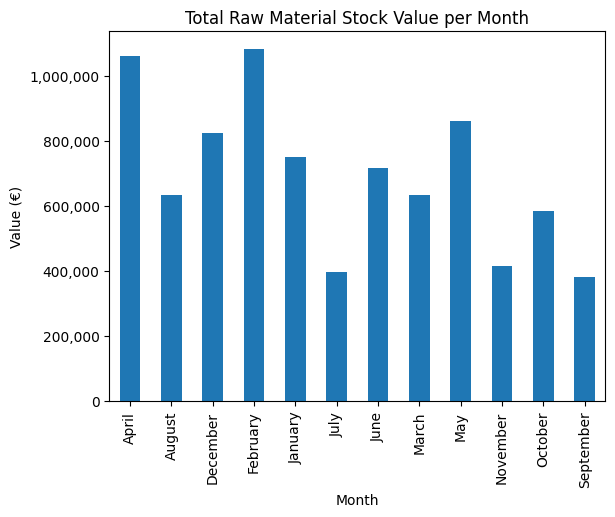

C:\Users\patri\AppData\Local\Temp\ipykernel_14232\2180009783.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scrap_rate_per_month = df_inventory_raw_material.groupby('Month')['Scrap Rate'].mean()


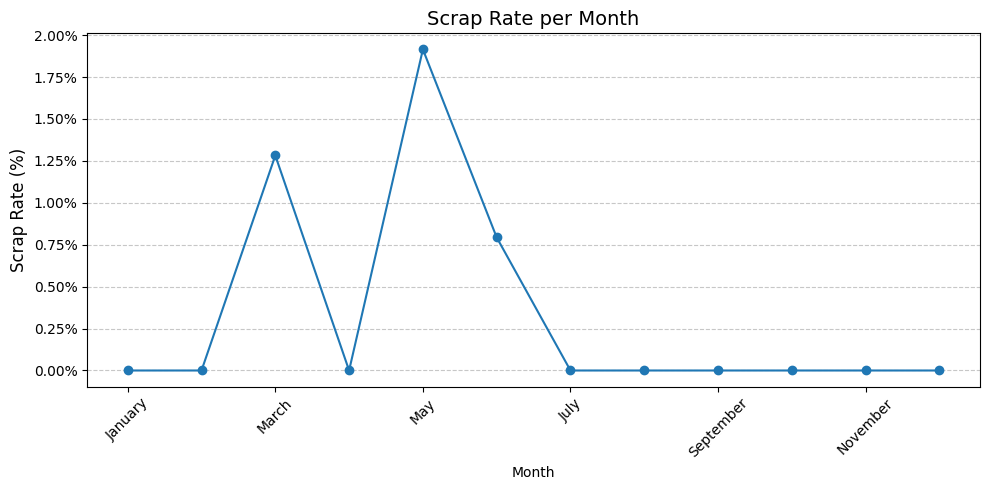

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Trend in voorraadwaarde
ax = df_inventory_raw_material.groupby('Month')['Stock value'].sum().plot(kind='bar')
plt.title('Total Raw Material Stock Value per Month')
plt.ylabel('Value (€)')
# Fix voor Y-as labels: laat grote getallen voluit zien
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()



# Neem absolute waarde van Scrapped
df_inventory_raw_material['Scrapped'] = df_inventory_raw_material['Scrapped'].abs()

# Scrap Rate berekenen
df_inventory_raw_material['Scrap Rate'] = df_inventory_raw_material['Scrapped'] / \
    (df_inventory_raw_material['Stock level'] + df_inventory_raw_material['Purchased'])

# Zorg dat Month chronologisch is
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df_inventory_raw_material['Month'] = pd.Categorical(df_inventory_raw_material['Month'], 
                                                    categories=month_order, ordered=True)

# Group by month en gemiddelde Scrap Rate berekenen
scrap_rate_per_month = df_inventory_raw_material.groupby('Month')['Scrap Rate'].mean()

# Plot
fig, ax = plt.subplots(figsize=(10,5))
scrap_rate_per_month.plot(kind='line', marker='o', ax=ax)
ax.set_title('Scrap Rate per Month', fontsize=14)
ax.set_ylabel('Scrap Rate (%)', fontsize=12)

# Y-as als percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks(rotation=45)  # Maanden leesbaar maken
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



### average machine utilization

In [6]:
#%pip install plotly
import plotly.express as px
import pandas as pd

import plotly.io as pio
pio.renderers.default = "browser"

# Berekening Utilization (als nog niet gedaan)
df_Roasting['Utilization'] = df_Roasting['Final weight /pbatch'] / df_Roasting['Max batch kg']

# Gemiddelde utilization per machine
utilization_avg = df_Roasting.groupby('Machine')['Utilization'].mean().reset_index()

# Plot met Plotly
fig = px.bar(utilization_avg,
             x='Machine',
             y='Utilization',
             text=utilization_avg['Utilization'].apply(lambda x: f'{x:.1%}'),  # Waarden boven de balk
             color='Machine',
             color_discrete_sequence=px.colors.qualitative.Set2,
             title='Average Machine Utilization per Machine')

# Y-as in percentage
fig.update_layout(yaxis=dict(title='Avg Utilization Rate (%)', tickformat=".0%"))

# Layout aanpassingen
fig.update_traces(textposition='outside')
fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')

fig.show()

# Berekening van gemiddelde per machine printen
print(utilization_avg)

# Berekening van gemiddelde per machine
utilization_avg = df_Roasting.groupby('Machine')['Utilization'].mean()
print(utilization_avg)



        Machine  Utilization
0    Probat P60     0.760971
1  Probat Px120     0.761040
Machine
Probat P60      0.760971
Probat Px120    0.761040
Name: Utilization, dtype: float64


### Province Sale Distribution By Product Roast

In [7]:
import plotly.graph_objects as go
import pandas as pd

# Total sales per province + product
df = df_E_com.groupby(['Ship to (province)', 'Product'])['Value'].sum().reset_index()

# List of provinces + "All" option
provinces = ['All'] + list(df['Ship to (province)'].unique())

# Create a figure
fig = go.Figure()

# Add a trace for each province
for province in provinces:
    if province == 'All':
        df_plot = df.groupby('Product')['Value'].sum().reset_index()
        total = df_plot['Value'].sum()
    else:
        df_plot = df[df['Ship to (province)'] == province]
        total = df_plot['Value'].sum()
    
    # Calculate percentage of total sales per province
    df_plot['Percent'] = df_plot['Value'] / total

    # Add bar trace
    fig.add_trace(
        go.Bar(
            x=df_plot['Product'],
            y=df_plot['Value'],
            name=province,
            visible=(province == 'All'),  # Only "All" visible initially
            text=[f'€{v:,.0f} ({p:.1%})' for v, p in zip(df_plot['Value'], df_plot['Percent'])],
            textposition='outside'
        )
    )

# Create dropdown buttons
buttons = []
for i, province in enumerate(provinces):
    visible = [False] * len(provinces)
    visible[i] = True
    buttons.append(dict(
        label=province,
        method="update",
        args=[{"visible": visible},
              {"title": f"Province Sale Distribution By Product Roast: {province}"}]
    ))

# Add dropdown menu
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons)],
    title="Province Sale Distribution By Product Roast",
    yaxis_title="Sales (€)",
    xaxis_title="Product"
)

# Show figure
fig.show()


C:\Users\patri\AppData\Local\Temp\ipykernel_14232\3713850732.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\patri\AppData\Local\Temp\ipykernel_14232\3713850732.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\patri\AppData\Local\Temp\ipykernel_14232\3713850732.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In [ ]:

#sort data
df_inventory_raw_material = (df_inventory_raw_material.sort_values(['Product', 'Supplier', 'Month']).reset_index(drop=True))

#compute previous month stock level
df_inventory_raw_material['Prev_stock'] = (df_inventory_raw_material.groupby(['Product', 'Supplier'])['Stock level'].shift(1))

#Calculate usage
df_inventory_raw_material['Scrapped'] = pd.to_numeric(df_inventory_raw_material['Scrapped'], errors='coerce').fillna(0)

df_inventory_raw_material['Purchased'] = pd.to_numeric(df_inventory_raw_material['Purchased'], errors='coerce').fillna(0)

df_inventory_raw_material['Usage'] = (df_inventory_raw_material['Prev_stock']+ df_inventory_raw_material['Purchased']- df_inventory_raw_material['Stock level']
    - df_inventory_raw_material['Scrapped'])

df_inventory_raw_material['Usage'] = (df_inventory_raw_material['Usage'].clip(lower=0).fillna(0))

# Daily usage 30 days/month 
df_inventory_raw_material['Daily_usage'] = (df_inventory_raw_material['Usage'] / 30)

# Round Days_on_hand to 2 decimals
df_inventory_raw_material['Days_on_hand'] = pd.to_numeric(df_inventory_raw_material['Days_on_hand'], errors='coerce').round(2)

# Days of Raw Material on Hand 
df_inventory_raw_material['Days_on_hand'] = (df_inventory_raw_material['Stock level']/ df_inventory_raw_material['Daily_usage'])
df_inventory_raw_material['Days_on_hand'] = df_inventory_raw_material['Days_on_hand'].replace([float('inf'), 1], pd.NA)

month_order = ['December', 'November', 'October', 'September', 'August', 'July', 'June', 'May', 'April', 'March', 'February', 'January' ]

df_inventory_raw_material['Month'] = pd.Categorical(df_inventory_raw_material['Month'], categories=month_order, ordered=True)

# Sort descending
df_inventory_raw_material = df_inventory_raw_material.sort_values(['Product', 'Month'], ascending=[True, False])

stock_days_per_product = df_inventory_raw_material[['Product', 'Month', 'Stock level', 'Days_on_hand']]
print(stock_days_per_product)



                        Product      Month  Stock level Days_on_hand
0   Coffee Beans (COO Colombia)    January        32057         <NA>
1   Coffee Beans (COO Colombia)   February        57513    49.263077
2   Coffee Beans (COO Colombia)      March        36599    26.731509
3   Coffee Beans (COO Colombia)      April        62871    55.137102
4   Coffee Beans (COO Colombia)        May        46222    36.027436
..                          ...        ...          ...          ...
67                 Shipping box     August        65000         97.5
68                 Shipping box  September        45000         67.5
69                 Shipping box    October        75000        112.5
70                 Shipping box   November        55000         82.5
71                 Shipping box   December        85000        127.5

[72 rows x 4 columns]


In [25]:
#%pip install nbformat
import plotly.graph_objects as go
import pandas as pd

# Clean and prepare your data 
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df_inventory_raw_material['Month'] = pd.Categorical(df_inventory_raw_material['Month'], categories=month_order, ordered=True)

# Sort data properly
df_inventory_raw_material = df_inventory_raw_material.sort_values(['Product', 'Month'])

# Get unique products
products = df_inventory_raw_material['Product'].unique()

# Create initial figure for first product 
first_product = products[0]
df_prod = df_inventory_raw_material[df_inventory_raw_material['Product'] == first_product]

fig = go.Figure()

# Bar for Stock Level
fig.add_trace(go.Bar(x=df_prod['Month'], y=df_prod['Stock level'], name='Stock Level', yaxis='y1'))

# Line for Days on Hand
fig.add_trace(go.Scatter(x=df_prod['Month'], y=df_prod['Days_on_hand'], name='Days on Hand', mode='lines+markers', yaxis='y2'))

# Dropdown menu for selecting product 
buttons = []
for product in products:
    df_p = df_inventory_raw_material[df_inventory_raw_material['Product'] == product]
    buttons.append(dict(method='update', label=product, args=[{
            'x': [df_p['Month'], df_p['Month']],
            'y': [df_p['Stock level'], df_p['Days_on_hand']]
        },
        {'title': f'Stock vs Days on Hand - {product}'}]
    ))

# Layout with dual axes and dropdown 
fig.update_layout(
    title=f'Stock vs Days on Hand - {first_product}',
    xaxis=dict(title='Month'),
    yaxis=dict(title='Stock Level', side='left'),
    yaxis2=dict(title='Days on Hand', overlaying='y', side='right'),
    legend=dict(x=0.02, y=0.98),
    updatemenus=[{
        'buttons': buttons,
        'direction': 'down',
        'showactive': True,
        'x': 0.15,
        'xanchor': 'left',
        'y': 1.1,
        'yanchor': 'top'
    }],
    height=600,
    template='plotly_white'
)

fig.show(renderer="browser")